# Aula 05

## Por que "Regressão" para classificar? A função sigmoide

A **Regressão Linear**, que prevê números contínuos, não é boa para determinarmos uma classe/categoria de dados, por exemplo, se um e-mail é SPAM (1) ou NÃO SPAM (0). Se usarmos a regressão linear, ela pode nos dar um resultado como 1.5 ou -3.2. Como interpretamos isso para uma categoria? Não faz sentido!

É aí que a **Regressão logística** entra. Ela recebe esse nome porque, matematicamente, a base dela é uma equação de regressão linear. A grande sacada é que ela pega o resultado dessa reta e o passa por um filtro matemático chamado **Função Sigmoide**.

A sigmoide tem um formato de `S` e sua principal característica é: não importa o quão grande ou negativo seja o número que entra, ela "esmaga" esse número para que ele saia sempre entre **0 e 1**:

$\sigma(z)=\frac{1}{1+e^{-z}}$

Se o resultado da sigmoide for **0.85**, o modelo está nos dizendo: "Tenho 85% de certeza de que isso pertence à classe 1".

Por padrão, se a probabilidade for maior ou igual a 0.5, o modelo prevê **1** (Sim). Se for menor, prevê **0** (Não).

## Classificação binária vs multiclasse: OvR e OvO

A regressão logística nasceu para ser **binária** (duas opções: 0 ou 1, gato ou cachorro, doente ou saudável). Mas e se tivermos 3 opções? (gato, cachorro ou pássaro). O Scikit-Learn é inteligente e adapta a regressão logística automaticamente usando duas abordagens:
1. **One-vs-Rest (OvR - Um contra o Resto):** O algoritmo treina 3 modelos separados. O modelo 1 tenta descobrir "é gato ou não é gato?". O modelo 2 tenta "é cachorro ou não é cachorro?". No final, o modelo com a maior probabilidade vence.

2. **One-vs-One (OvO - Um contra Um):** O algoritmo treina modelo para todas as combinações possíveis de pares: gato vs cachorro,  cachorro vs pássaro, gato vs pássaro. A classe que vencer mais "duelos" é a escolhida.

Vamos focar no bem feito: a classificação binária:

In [ ]:
# Importar as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
# CCarregar o dataset
dados = load_breast_cancer()
X = dados.data
y = dados.target  # 0: maligno / 1: benigno

# Divisão em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Pré-processamento: escalonamento
# A regressão logística é sensível à escala dos dados
# É necessário colocar as variáveis na mesma régua
scaler = StandardScaler()
X_treino_escalonado = scaler.fit_transform(X_treino)
X_teste_escalonado = scaler.transform(X_teste)

# Criar e treinar o modelo
modelo = LogisticRegression()
modelo.fit(X_treino_escalonado, y_treino)

# Fazer as previsões
previsao = modelo.predict(X_teste_escalonado)  # retorna a classe (0 ou 1)
probabilidades = modelo.predict_proba(X_teste_escalonado)  # retorna as probabilidades

print(f'''Classe prevista para o primeiro paciente: {previsao[0]}
Probabilidade [maligno, benigno]: {probabilidades[0]}''')

Classe prevista para o primeiro paciente: 1
Probabilidade [maligno, benigno]: [0.1179591 0.8820409]


## As métricas vitais: matriz de confusão e derivados

Se o nosso modelo errar 1% das vezes, isso é bom? Depende do erro! Imagine o nosso modelo de câncer. Se ele erra dizendo que uma pessoa saudável está doente, a pessoa fará exames desnecessários (meio chato, mas contornável). Mas se o modelo erra dizendo que uma pessoa está saudável, a pessoa vai para casa e não trata o câncer (fatal).

Para analisar isso detalhadamente, usamos a **Matriz de Confusão**:

- **VP (Verdadeiro Positivo):** O modelo disse que tem câncer, e realmente tem.

- **VN (Verdadeiro Negativo):** O modelo disse que é saudável, e realmente é.

- **FP (Falso Positivo):** O modelo disse que tem câncer, mas é saudável (alarme falso).

- **FN (Falso Negativo)**: O modelo disse que é saudável, mas tem câncer (erro fatal).

A partir desses 4 quadrantes, calculamos:

1. **Acurácia (Accuracy):** Do total, quantos eu acertei? (pode enganar se os dados forem desbalanceados):

$\frac{VP+VN}{Total}$

2. **Precisão (Precision):** De todos que classifiquei como "Positivo", quantos realmente eram positivos? (foca em diminuir os Falsos Positivos):

$\frac{VP}{VP+FP}$

3. **Recall (sensibilidade):** De todos os Positivos **REAIS** que existiam, quantos o meu modelo conseguiu encontrar? (foca em diminuir os falsos negativos, vital para hospitais):

$\frac{VP}{VP+FN}$

4. **F1-Score:** Uma média harmônica entre Precisão e Recall. Ótimo para comparar modelos de forma resumida:

$\frac{2VP}{2VP+FP+FN}$

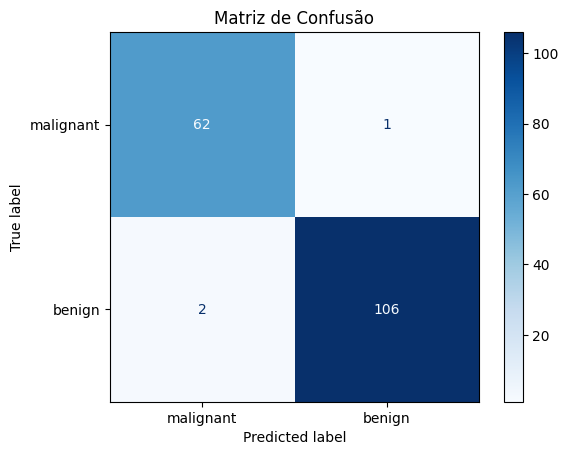

              precision    recall  f1-score   support

   malignant       0.97      0.98      0.98        63
      benign       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [ ]:
# Criar a matriz de confusão
from sklearn.metrics import (confusion_matrix,
                             ConfusionMatrixDisplay,
                             classification_report)

# Plotar a matriz de confusão
matriz = confusion_matrix(y_teste, previsao)
grafico = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=dados.target_names
)
grafico.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

# Gerar o relatório completo de métricas
# O Scikit-Learn faz todos os cálculos complexos em uma única linha
print(classification_report(y_teste, previsao, target_names=dados.target_names))

## Curva ROC e AUC: avaliando probabilidades

Por padrão, o Scikit-Learn corta a probabilidade no 0.5. Mas em um hospital, talvez o médico queira mudar essa regra: "Se o modelo der apenas 30% de chance de câncer, já quero classificar como Positivo e investigar e não correr riscos".

A **Curva ROC** plota o desempenho do nosso modelo em **todos os pontos de corte possíveis**, de 0.0 a 1.0. Ela cruza a *Taxa de Verdadeiros Positivos* (nosso acerto) com a *Taxa de Falsos Positivos* (nosso erro de alarme falso).

A área embaixo dessa curva se chama **AUC (Area Under the Curve):**

- AUC = 0.5: O modelo é terrível, é igual jogar uma moeda para cima.

- AUC entre 0.7 e 0.8: Um modelo aceitável

- AUC entre 0.8 e 0.9: Um modelo excelente.

- AUC = 1.0: Um modelo perfeito, ou cocorreu um vazamento de dados, desconfie!

- Geralmente, um AUC acima de 0.8 ou  0.9 é considerado excelente.

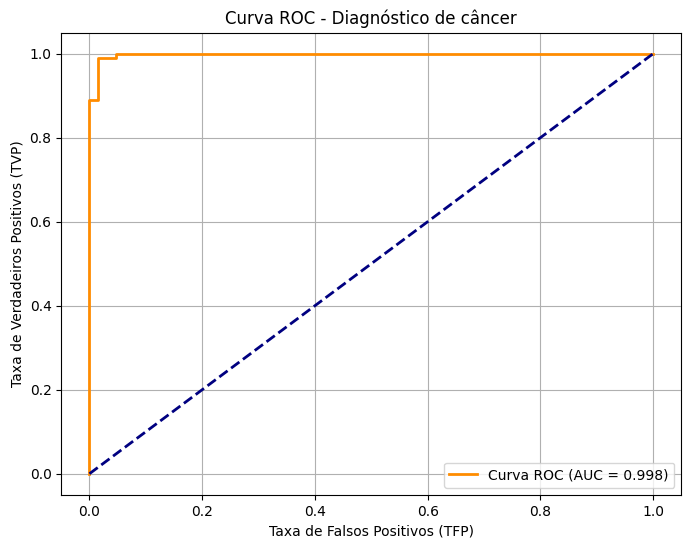

In [ ]:
# Calcular o ROC e AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Obter as probabilidades de classe positiva
probabilidades_positivas = probabilidades[:, 1]

# Calcular os pontos da curva
tfp, tvp, _ = roc_curve(y_teste, probabilidades_positivas)

# Calcular a área (AUC)
auc_score = roc_auc_score(y_teste, probabilidades_positivas)

# Plotar o gráfico
plt.figure(figsize=(8, 6))
plt.plot(tfp, tvp, color='darkorange',
         lw=2,
          label=f'Curva ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0,1], color='navy', lw=2, linestyle='--')  # linha base (chute)
plt.xlabel('Taxa de Falsos Positivos (TFP)')
plt.ylabel('Taxa de Verdadeiros Positivos (TVP)')
plt.title('Curva ROC - Diagnóstico de câncer')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Para desenhar essa curva, o gráfico cruza duas métricas matemáticas essenciais:

- **Eixo Y (TVP - Taxa de Verdedeiros Positivos):** É a nossa Taxa de Acertos de casos positivos, ou seja, o nosso recall (sensibilidade).

- **Eixo X (TFP - Taxa de Falsos Positivos):** É a nossa Taxa de Alarme Falso, Quantos pacientes saudáveis nós dissemos erroneamente que estavam doentes?

O cenário ideal é estarmos no **canto superior esquerdo** do gráfico: 100% de Acerto (TVP = 1) e 0% de Alarme Falso (TFP = 0).

A linha tracejada diagonal no meio do gráfico representa um modelo "chutador" (jogar uma moeda para cima). Se a sua curva ROC estiver em cima dessa linha tracejada, seu modelo é inútil.

Observe o nosso gráfico gerado. A curva laranja sobre rapidamente em direção ao canto superior esquerdo, o que significa que conseguimos capturar quase todos os doentes antes de começarmos a disparar falsos alarmes. A área embaixo dessa curva (AUC) é bem próxima de 1, provando que a nossa regressão logística fez um excelente trabalho em separar matematicamente o que é um tumor benigno de um maligno.